In [1]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import RNA
from scipy.special import gammaln


In [2]:
pop1 = '80'
reg_weight_str = 'main'
#df_mutations = pd.read_csv("/home/mauro-maglione/Documents/MERGE-RNA/fits_paper/designed_sequence/outputs/synthetic_bistable_main/synthetic_bistable_" + pop1 + "/detailed/data/bistable_synthetic_"+pop1+"_50mM_r0.csv")
df_mutations = pd.read_csv("/u/m/mmaglion/Documents/MERGE-RNA_restored/fits_paper/designed_sequence/outputs/synthetic_bistable_main/synthetic_bistable_80/detailed/data/bistable_synthetic_80_50mM_r0.csv")

sequence = df_mutations.ref_nt.values
mutation_counts = df_mutations.mut_count.values
coverage_per_site = df_mutations.total_count.values

print(sequence)

['U' 'A' 'A' 'U' 'A' 'C' 'G' 'A' 'C' 'U' 'C' 'A' 'C' 'U' 'A' 'U' 'A' 'G'
 'G' 'G' 'C' 'A' 'U' 'U' 'A' 'U' 'G' 'C' 'C' 'A' 'C' 'A' 'G' 'C' 'C' 'A'
 'A' 'U' 'C' 'C' 'C' 'C' 'A' 'C' 'U' 'U' 'C' 'A' 'A' 'C' 'U' 'C' 'A' 'C'
 'A' 'A' 'C' 'U' 'A' 'U' 'U' 'C' 'C' 'A' 'A' 'A' 'A' 'A' 'A' 'U' 'U' 'G'
 'G' 'A' 'A' 'U' 'A' 'G' 'U' 'U' 'G' 'U' 'G' 'A' 'G' 'U' 'U' 'G' 'A' 'A'
 'G' 'U' 'G' 'G' 'G' 'G' 'A' 'U' 'U' 'A' 'A' 'A' 'A' 'A' 'A' 'U' 'C' 'C'
 'C' 'C' 'A' 'C' 'U' 'U' 'C' 'A' 'A' 'C' 'U' 'C' 'A' 'C' 'A' 'A' 'C' 'U'
 'A' 'U' 'U' 'C' 'C' 'A' 'A' 'C' 'C' 'U' 'C' 'C' 'A' 'G' 'C' 'A' 'G' 'A'
 'C' 'C' 'A' 'U']


In [ ]:
df_mutations_2 = pd.read_csv("/u/m/mmaglion/Documents/MERGE-RNA_restored/fits_paper/designed_sequence/outputs/experimental_turner/phase1/newseqWT/detailed/data/NewseqWT_40mM_r1.csv")

mutation_counts = np.zeros(len(sequence), dtype=int)
coverage_per_site = np.zeros(len(sequence), dtype=int)

for i in df_mutations_2.pos.values:
    mutation_counts[i-1] = df_mutations_2[df_mutations_2.pos==i].mut_count.values[0]
    coverage_per_site[i-1] = df_mutations_2[df_mutations_2.pos==i].total_count.values[0]

In [3]:
seq = "".join(sequence)
fc=RNA.fold_compound(seq)
fc.pf()
bpp=fc.bpp()
bpp = np.array(fc.bpp())[1:,1:]
bpp+=bpp.T
bpp=np.sum(bpp,axis=0)

### 1.1 Try to compute the parameters of the expansion from scratch

In [4]:
# def convert_p_bind_1d_to_dict(p_bind_1d, DMS_mode=True):
#     '''Convert the 1D array of p_bind to a dictionary.
#     If DMS_mode is True, input is a 4-element array and will put 0A, 0C to 0 and 1G, 1U to equal to  0G, 0U.'''
#     if DMS_mode:
#         p_bind_dict = {key: value for key, value in zip([(0, 'A'), (0, 'C'), (0, 'G'), (0, 'U')], p_bind_1d)}
#         p_bind_dict[(1, 'A')] = 0
#         p_bind_dict[(1, 'C')] = 0
#         p_bind_dict[(1, 'G')] = p_bind_dict[(0, 'G')]
#         p_bind_dict[(1, 'U')] = p_bind_dict[(0, 'U')]
#     else:
#         p_bind_dict = {key: value for key, value in zip([(0, 'A'), (0, 'C'), (0, 'G'), (0, 'U'), (1, 'A'), (1, 'C'), (1, 'G'), (1, 'U')], p_bind_1d)}
#     return p_bind_dict

def convert_p_bind_1d_to_dict(p_bind_1d, DMS_mode=True):
    '''Convert the 1D array of p_bind to a dictionary.
    If DMS_mode is True, input is a 4-element array and will put 0A, 0C to 0 and 1G, 1U to equal to  0G, 0U.'''
    list_partial_keys = ["p_bind_A_", "p_bind_C_", "p_bind_G_", "p_bind_U_"]
    if DMS_mode:
        p_bind_dict = {incom_key+"0": value for incom_key, value in zip(list_partial_keys, p_bind_1d)}
        p_bind_dict["p_bind_A_"+"1"] = 0
        p_bind_dict["p_bind_C_"+"1"] = 0
        p_bind_dict["p_bind_G_"+"1"] = p_bind_dict["p_bind_G_"+"0"]
        p_bind_dict["p_bind_U_"+"1"] = p_bind_dict["p_bind_U_"+"0"]
    else:
        list_keys = []

        for str in ["0", "1"]:
            list_keys.append(str.join(list_partial_keys))

        p_bind_dict = {key: value for key, value in zip(list_keys, p_bind_1d)}
    return p_bind_dict

In [5]:
def pack_params(params_1d, dict_with_phys_params_pos):
    '''Unpacks the 1D array of parameters into a dictionary.'''
    params = {}
    for param, pos in dict_with_phys_params_pos.items():
        params[param] = params_1d[pos]
    # Convert the 1D array for p_bind into a dictionary.
    p_bind_dict = convert_p_bind_1d_to_dict(params['p_bind'])
    # maybe I will implement the test later
    return params

In [6]:
def _generate_phys_params_positions(DMS_mode=True):
    '''Generate parameter positions mapping'''
    base_config = {
        'mu_r': 0,
        'p_b': 1,
        'p_bind': list(range(2, 10 if not DMS_mode else 6)),
        'm0': 10 if not DMS_mode else 6,
        'm1': 11 if not DMS_mode else 7,
    }
    params_pos = base_config.copy()
    return params_pos

In [7]:
pos_dict = _generate_phys_params_positions()
print(pos_dict)

{'mu_r': 0, 'p_b': 1, 'p_bind': [2, 3, 4, 5], 'm0': 6, 'm1': 7}


In [8]:
#vec_phys_params = np.loadtxt("/home/mauro-maglione/Documents/MERGE-RNA/fits_paper/designed_sequence/outputs/synthetic_bistable_main/synthetic_bistable_" + pop1 + "/params1D.txt")
vec_phys_params = np.loadtxt("/u/m/mmaglion/Documents/MERGE-RNA_restored/fits_paper/designed_sequence/outputs/synthetic_bistable_main/synthetic_bistable_80/params1D.txt")
#vec_phys_params = np.loadtxt("/u/m/mmaglion/Documents/MERGE-RNA_restored/fits_paper/designed_sequence/outputs/experimental_turner/phase1/newseqWT/params1D.txt")

phys_params_dict = pack_params(vec_phys_params,pos_dict)
print(phys_params_dict)

{'mu_r': np.float64(0.40456049704138497), 'p_b': np.float64(0.14104732947920853), 'p_bind': array([0.36251399, 0.23412978, 0.06800555, 0.00203605]), 'm0': np.float64(0.001065791888193865), 'm1': np.float64(0.6852534778035398)}


In [9]:
#test of convert_p_bind_1d_to_dict
dict_pbind = convert_p_bind_1d_to_dict(phys_params_dict["p_bind"]) 
print(dict_pbind)

{'p_bind_A_0': np.float64(0.3625139900464584), 'p_bind_C_0': np.float64(0.23412977556368655), 'p_bind_G_0': np.float64(0.06800555472301946), 'p_bind_U_0': np.float64(0.002036046728995221), 'p_bind_A_1': 0, 'p_bind_C_1': 0, 'p_bind_G_1': np.float64(0.06800555472301946), 'p_bind_U_1': np.float64(0.002036046728995221)}


In [10]:
#I miss temperature and concentration --> retrieved from fit_metadata.json
phys_const_from_fit_metadata = {"temp_C": 37, "conc_mM": 40}

In [11]:
#now I retrieve the eps form .npy file
#eps_path = "/home/mauro-maglione/Documents/MERGE-RNA/fits_paper/designed_sequence/outputs/synthetic_bistable_main/synthetic_bistable_" + pop1 + "/detailed/bistable_synthetic_"+pop1+"_eps_b.npy"
eps_path = "/u/m/mmaglion/Documents/MERGE-RNA_restored/fits_paper/designed_sequence/outputs/synthetic_bistable_main/synthetic_bistable_80/detailed/bistable_synthetic_80_eps_b.npy"
eps_vec = np.load(eps_path, mmap_mode=None, allow_pickle=False, fix_imports=True, encoding='ASCII')

In [12]:
print(eps_vec)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


I write the function in order to give the coefficients of the mutation rate in the form:
$$
M_i = a_i+b_i\,s_i
$$
But maybe it could be better to use an expression like the following to neglect some cancellation that happens in $b_i$ where there is a difference between two close numbers
$$
M_i = 1-a_i+(a_i-b_i)s_i
$$
The two close numbers are 
$$
\frac{e^{\beta \, \mu}}{1+ e^{\beta \, \mu}} \qquad \frac{e^{\beta \, (\mu - \Delta \mu)}}{1+ e^{\beta \, (\mu - \Delta \mu)}}
$$
When the nucleotides are U or G, since in their case the p_bind is independent of the contact state of the nucleotide

In [13]:
# def mut_prob_condit_contact(seq,eps_b,*,
#                             conc_mM,temp_C,
#                             #p_bind_A_0, p_bind_A_1, p_bind_U_0, p_bind_U_1, p_bind_C_0, p_bind_C_1,p_bind_G_0, p_bind_G_1,
#                             p_bind,
#                             mu_r, p_b, m0, m1):
    
#     kBT = (273.15 + temp_C) * (1.98717/1000) # kcal/mol, matches fit.py's self.kBT = self.temp_K * kb
#     beta = 1/kBT
#     mu_j = mu_r + kBT * np.log((conc_mM+.1)/1000) if conc_mM is not None else mu_r
#     exp_mu = np.exp(beta*mu_j)
#     exp_mu_prime = np.exp(beta*(mu_j-p_b))

#     def mut_prob_without_contact_pos_i(p_bind_0, eps_i):
#         prob_mut_without_chem = np.exp(-eps_i)*(np.exp(-m0)/(1+exp_mu))
#         prob_mut_with_chem = np.exp(-eps_i)*(((np.exp(-m0)*(1-p_bind_0) + np.exp(-m1)*p_bind_0)*exp_mu/(1+exp_mu)))
#         return  prob_mut_without_chem + prob_mut_with_chem

#     def mut_prob_with_contact_pos_i(p_bind_1, eps_i):
#         prob_mut_without_chem = np.exp(-eps_i)*(np.exp(-m0)/(1+exp_mu_prime))
#         prob_mut_with_chem = np.exp(-eps_i)*(((np.exp(-m0)*(1-p_bind_1) + np.exp(-m1)*p_bind_1)*exp_mu_prime/(1+exp_mu_prime)))
#         return  prob_mut_without_chem + prob_mut_with_chem
    
#     dict_pbind = convert_p_bind_1d_to_dict(p_bind) 

#     a = np.zeros(len(seq),float)
#     b = np.zeros(len(seq),float)

#     i = 0
#     for nucleot in seq:
#         eps_ = eps_b[i]
#         a_prime = mut_prob_without_contact_pos_i(dict_pbind["p_bind_"+nucleot+"_0"], eps_)
#         a[i] = 1 - a_prime
#         b[i] = a_prime - mut_prob_with_contact_pos_i(dict_pbind["p_bind_"+nucleot+"_1"], eps_)
#         i +=1
        
#     return a, b

In [14]:
def mut_prob_condit_contact(seq,eps_b,*,
                            conc_mM,temp_C,
                            #p_bind_A_0, p_bind_A_1, p_bind_U_0, p_bind_U_1, p_bind_C_0, p_bind_C_1,p_bind_G_0, p_bind_G_1,
                            p_bind,
                            mu_r, p_b, m0, m1):
    
    kBT = (273.15 + temp_C) * (1.98717/1000) # kcal/mol, matches fit.py's self.kBT = self.temp_K * kb
    beta = 1/kBT
    mu_j = mu_r + kBT * np.log((conc_mM+.1)/1000) if conc_mM is not None else mu_r
    f_mu = np.exp(beta*mu_j)/(1-np.exp(beta*mu_j))
    f_mu_prime = np.exp(beta*(mu_j-p_b))/(1-np.exp(beta*(mu_j-p_b)))

    def compute_a_i(p_bind_0, eps_i):
        f_0 = 1-np.exp(-eps_i-m0)
        f_1 = 1-np.exp(-eps_i-m1)
        return  f_0+(f_1-f_0)*f_mu*p_bind_0

    def compute_b_i(p_bind_0, p_bind_1, eps_i):
        f_0 = 1-np.exp(-eps_i-m0)
        f_1 = 1-np.exp(-eps_i-m1)
        return  (f_1-f_0)*(f_mu_prime*p_bind_1-f_mu*p_bind_0)
    
    dict_pbind = convert_p_bind_1d_to_dict(p_bind) 

    a = np.zeros(len(seq),float)
    b = np.zeros(len(seq),float)

    i = 0
    for nucleot in seq:
        eps_pos = eps_b[i]
        a[i] = compute_a_i(dict_pbind["p_bind_"+nucleot+"_0"], eps_pos)
        b[i] = compute_b_i(dict_pbind["p_bind_"+nucleot+"_0"], dict_pbind["p_bind_"+nucleot+"_1"], eps_pos)
        i +=1
        
    return a, b

In [15]:
a_from_fit, b_from_fit = mut_prob_condit_contact(sequence, eps_vec, **phys_const_from_fit_metadata, **phys_params_dict)

### 1.1 cheks for underflow

In [ ]:
def check_exp_argument_ranges(eps_b, *, conc_mM, temp_C, mu_r, p_b, m0, m1, verbose=True):
    '''Report any argument fed into np.exp() in mut_prob_condit_contact that falls outside
    float64's safe exp domain [-745, 709] (below underflows to exactly 0.0, above overflows to inf).'''
    kBT = (273.15 + temp_C) * (1.98717/1000)
    beta = 1/kBT
    mu_j = mu_r + kBT * np.log((conc_mM+.1)/1000) if conc_mM is not None else mu_r

    args = {
        "beta*mu_j": np.atleast_1d(beta*mu_j),
        "beta*(mu_j-p_b)": np.atleast_1d(beta*(mu_j-p_b)),
        "-eps_b": -np.asarray(eps_b, dtype=float),
        "-m0": np.atleast_1d(-m0),
        "-m1": np.atleast_1d(-m1),
    }

    safe_lo, safe_hi = -745.0, 709.0
    any_unsafe = False
    for name, values in args.items():
        bad = (values < safe_lo) | (values > safe_hi)
        if np.any(bad):
            any_unsafe = True
            print(f"[UNSAFE] {name}: {bad.sum()}/{values.size} value(s) outside exp-safe range "
                  f"[{safe_lo}, {safe_hi}] (min={values.min():.3g}, max={values.max():.3g})")
        elif verbose:
            print(f"[ok] {name}: min={values.min():.3g}, max={values.max():.3g}")
    if not any_unsafe:
        print("All exp() arguments are within the safe float64 range.")
    return not any_unsafe


def mut_prob_condit_contact_checked(seq, eps_b, **kwargs):
    '''Run mut_prob_condit_contact with numerical guards: raises on overflow/invalid ops,
    warns on underflow, and checks outputs for nan/inf/silent-zero afterwards.'''
    range_kwargs = {k: v for k, v in kwargs.items() if k in ("conc_mM", "temp_C", "mu_r", "p_b", "m0", "m1")}
    check_exp_argument_ranges(eps_b, **range_kwargs)

    with np.errstate(over='raise', invalid='raise', under='warn'):
        a, b = mut_prob_condit_contact(seq, eps_b, **kwargs)

    if not (np.all(np.isfinite(a)) and np.all(np.isfinite(b))):
        bad_a = np.where(~np.isfinite(a))[0]
        bad_b = np.where(~np.isfinite(b))[0]
        raise FloatingPointError(f"Non-finite output: a positions {bad_a}, b positions {bad_b}")

    suspicious_zero = (a == 0.0) | (b == 0.0)
    if np.any(suspicious_zero):
        print(f"[warn] exact-zero output at position(s) {np.where(suspicious_zero)[0]} "
              f"-- possible silent underflow, verify these are physically expected")

    return a, b

In [ ]:
# Diagnostic pass on the currently loaded (synthetic_bistable_0) example: verifies exp()
# arguments stay in the safe float64 range and outputs are finite / not silently zero.
a_checked, b_checked = mut_prob_condit_contact_checked(sequence, eps_vec, **phys_const_from_fit_metadata, **phys_params_dict)
assert np.allclose(a_checked, a_from_fit) and np.allclose(b_checked, b_from_fit)

In [ ]:
# Stress test with more extreme fitted values (cspA fit: p_b=1.70, larger than the
# synthetic_bistable_0 example) to confirm the diagnostic actually catches out-of-range
# exp() arguments. Reuses the already-loaded sequence/eps_b, swapping in cspA's mu_r/p_b/m0/m1.
cspa_params_1d = np.loadtxt("/home/mauro-maglione/Documents/MERGE-RNA/fits_paper/cspA/fix_1/cspA_comb_0_with_lambdas/params1D.txt")
cspa_phys_params_dict = pack_params(cspa_params_1d, pos_dict)
print({k: v for k, v in cspa_phys_params_dict.items() if k != "p_bind"})

stress_params_dict = dict(phys_params_dict)
for key in ("mu_r", "p_b", "m0", "m1"):
    stress_params_dict[key] = cspa_phys_params_dict[key]

a_stress, b_stress = mut_prob_condit_contact_checked(sequence, eps_vec, **phys_const_from_fit_metadata, **stress_params_dict)

In [ ]:
# positions along the sequence
positions = np.arange(1, len(sequence) + 1)

# a_from_fit is the array you already computed
y = a_from_fit
y2 = a_from_fit+b_from_fit

plt.figure(figsize=(14, 4))
ax = plt.gca()

ax.plot(positions, y, marker='o', linestyle='-', linewidth=1.2, color='tab:blue')

# add nucleotide letters near each point
for x, yy, nt in zip(positions, y, sequence):
    ax.annotate(
        nt,
        xy=(x, yy),
        xytext=(0, 8),           # offset upward
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        color="red"
    )

ax.plot(positions, y2, marker='o', linestyle='-', linewidth=1.2, color='tab:orange')

ax.set_xticks(positions[::7])

ax.set_xlabel("Sequence position")
ax.set_ylabel(r"$a_i$")
ax.set_title(r"Values of $a_i$ along the sequence")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# positions along the sequence
positions = np.arange(1, len(sequence) + 1)

# b_from_fit is the array you already computed
y = b_from_fit

plt.figure(figsize=(14, 4))
ax = plt.gca()

ax.plot(positions, y, marker='o', linestyle='-', linewidth=1.2, color='tab:blue')

# add nucleotide letters near each point
for x, yy, nt in zip(positions, y, sequence):
    ax.annotate(
        nt,
        xy=(x, yy),
        xytext=(0, 8),           # offset upward
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        color="red"
    )

ax.set_xticks(positions[::7])

ax.set_xlabel("Sequence position")
ax.set_ylabel(r"$b_i$")
ax.set_title(r"Values of $b_i$ along the sequence")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 1.2 Comput loss to see they parameters are correct

We verify these where the values obtained by the merge_rna fit after the phase 1

In [16]:
def log_binomial(n, k):
    '''Compute the log of the binomial coefficient n choose k. Gammaln is an efficient way to compute the log of the factorial.'''
    return gammaln(n + 1) - gammaln(k + 1) - gammaln(n - k + 1)

In [17]:
def my_mut_rate_profile(prob_base_pair, a, b):
    return a+b*prob_base_pair

In [18]:
#I cut out the function the gradient part and the use of the position mask
def loss_binomial(*, mut_rate_model, mut_obs, coverage):
    """
    Compute the negative log-likelihood loss and (not) its gradient with respect to the parameters.
    Experimental data is retrieved from Experiment.df.
    Inputs:
        mut_rate_model: np.array, predicted mutation profile (values in (0,1))
        grad_of_mut_rate:    np.array, derivative matrix of the mutation profile with respect to parameters.
        compute_gradient: bool, whether to compute the gradient.
    Returns:
        loss: scalar, the negative log-likelihood loss.
        grad:  np.array containing the gradient with respect to parameters (or None if grad_of_mut_rate is None).
    """
    
    # Apply position mask to exclude masked positions from loss calculation
    ### not for now I do not mask positions
    # mut_obs_masked = mut_obs[self.position_mask]
    # coverage_masked = coverage[self.position_mask] 
    # mut_rate_model_masked = mut_rate_model[self.position_mask]
    mut_obs_masked = mut_obs
    coverage_masked = coverage
    mut_rate_model_masked = mut_rate_model
    # Numerical guard: prevent log/division singularities at exactly 0 or 1.
    # Keep epsilon tiny so low mutation-rate regime is not materially altered.
    eps_num = 1e-15
    mut_rate_model_masked = np.clip(mut_rate_model_masked, eps_num, 1.0 - eps_num)
    
    
    # Compute log of the binomial coefficient for each position
    log_binom = np.array([log_binomial(cov, mut) for cov, mut in zip(coverage_masked, mut_obs_masked)])
    # Compute the log-likelihood at each position
    log_prob = log_binom + (mut_obs_masked * np.log(mut_rate_model_masked) +
                            (coverage_masked - mut_obs_masked) * np.log(1 - mut_rate_model_masked))
    # Total negative log-likelihood loss (only from unmasked positions)
    loss = -np.sum(log_prob)
    
    return loss

In [19]:
loss_binomial(mut_rate_model=my_mut_rate_profile(bpp,a_from_fit, b_from_fit), mut_obs=mutation_counts, coverage=coverage_per_site)

np.float64(1485.7860009986016)

### 1.3 Compute expansion from merge RNA

In [20]:
def mut_prob_condit_contact_merge_rna(seq,eps_b,*,
                            conc_mM,temp_C,
                            #p_bind_A_0, p_bind_A_1, p_bind_U_0, p_bind_U_1, p_bind_C_0, p_bind_C_1,p_bind_G_0, p_bind_G_1,
                            p_bind,
                            mu_r, p_b, m0, m1):
    
    kBT = (273.15 + temp_C) * (1.98717/1000) # kcal/mol, matches fit.py's self.kBT = self.temp_K * kb
    beta = 1/kBT
    mu_j = mu_r + kBT * np.log((conc_mM+.1)/1000) if conc_mM is not None else mu_r
    f_mu = np.exp(beta*mu_j)/(1-np.exp(beta*mu_j))
    f_mu_prime = np.exp(beta*(mu_j-p_b))/(1-np.exp(beta*(mu_j-p_b)))

    dict_pbind = convert_p_bind_1d_to_dict(p_bind) 

    def compute_penalty_m(mu, p_b_):
        '''Compute the penalty for paired bases in kcal/mol'''
        mu_prime = mu-p_b_
        penalty_in_kbt = -math.log((1+math.exp(beta*mu_prime))/(1+math.exp(beta*mu)))
        penalty_in_kcal_per_mol = penalty_in_kbt * kBT #TBC: to be checked
        return penalty_in_kcal_per_mol

    def compute_mu_dependent_quantities(mu, p_b_):
        '''Returns some key quantities that depend on mu: e^beta*mu, e^beta*mu', p(c_b|s_b,n_b)'''
        mu_prime = mu - p_b_
        e_beta_mu = math.exp(beta*mu)
        e_beta_mu_prime = math.exp(beta*mu_prime)
        e_beta_mu_norm = e_beta_mu / (1 + e_beta_mu)
        e_beta_mu_prime_norm = e_beta_mu_prime / (1 + e_beta_mu_prime)
        # probability of chemical binding
        p_cb_given_sb_nb = dict() # p(cb=1|s_b,n_b) -> p_cb[(s_b,n_b)] , cb = 1 is implicit.
        for s_b in [0, 1]:
            physical_binding_probability = e_beta_mu_norm if s_b == 0 else e_beta_mu_prime_norm
            for n_b in ['A', 'C', 'G', 'U']:
                p_cb_given_sb_nb[(s_b, n_b)] = dict_pbind["p_bind_"+n_b+"_"+str(s_b)] * physical_binding_probability # p(cb=0|s_b,n_b) = 1 - p(cb=1|s_b,n_b)
        return e_beta_mu, e_beta_mu_prime, p_cb_given_sb_nb

    def compute_p_cb(mu, p_b_, pairing_probs):
        '''Compute p(c_b) for the whole sequence'''
        # compute mu dependent quantities (and p(c_b|s_b,n_b))
        _, _, p_cb_given_sb_nb = compute_mu_dependent_quantities(mu, p_b_)
        # apply penalty for paired bases
        penalty = compute_penalty_m(mu, p_b_)
        # compute p(s_b)
        try:
            assert 0 <= penalty <= 5
        except AssertionError:
            print('Warning, penalty is not in [0,5]')
            print(f'penalty: {penalty}, mu: {mu}, p_b: {p_b}')
        # compute p(c_b)
        p_cb = np.zeros(len(seq))
        for i,nb in enumerate(seq):    # weighted sum over s_b=0,1
            p_cb[i] = p_cb_given_sb_nb[(1, nb)]*pairing_probs[i] + p_cb_given_sb_nb[(0, nb)]*(1-pairing_probs[i])
        return p_cb

    # 2a: mutation profile model
    def compute_mutation_profile(m0, m1,eps_b, p_cb):
        '''Compute the mutation profile predicted by the model with the current parameters.
        Later: compute its derivatives'''
        # compute mutation profile
        Mb = 1 - np.exp(-eps_b) * (math.exp(-m0) +  p_cb*(math.exp(-m1) - math.exp(-m0)))
        return Mb
    
    a_merge = compute_mutation_profile(m0, m1, eps_b, compute_p_cb(mu_j, p_b, np.zeros(len(seq))))
    a_plus_b_merge = compute_mutation_profile(m0, m1, eps_b, compute_p_cb(mu_j, p_b, np.ones(len(seq))))
    return a_merge, a_plus_b_merge-a_merge

In [21]:
a_from_merge, b_from_merge = mut_prob_condit_contact_merge_rna(sequence, eps_vec, **phys_const_from_fit_metadata, **phys_params_dict)

In [22]:
a_from_merge

array([0.00113754, 0.01394139, 0.01394139, 0.00113754, 0.01394139,
       0.0093813 , 0.00348072, 0.01394139, 0.0093813 , 0.00113754,
       0.0093813 , 0.01394139, 0.0093813 , 0.00113754, 0.01394139,
       0.00113754, 0.01394139, 0.00348072, 0.00348072, 0.00348072,
       0.0093813 , 0.01394139, 0.00113754, 0.00113754, 0.01394139,
       0.00113754, 0.00348072, 0.0093813 , 0.0093813 , 0.01394139,
       0.0093813 , 0.01394139, 0.00348072, 0.0093813 , 0.0093813 ,
       0.01394139, 0.01394139, 0.00113754, 0.0093813 , 0.0093813 ,
       0.0093813 , 0.0093813 , 0.01394139, 0.0093813 , 0.00113754,
       0.00113754, 0.0093813 , 0.01394139, 0.01394139, 0.0093813 ,
       0.00113754, 0.0093813 , 0.01394139, 0.0093813 , 0.01394139,
       0.01394139, 0.0093813 , 0.00113754, 0.01394139, 0.00113754,
       0.00113754, 0.0093813 , 0.0093813 , 0.01394139, 0.01394139,
       0.01394139, 0.01394139, 0.01394139, 0.01394139, 0.00113754,
       0.00113754, 0.00348072, 0.00348072, 0.01394139, 0.01394

In [23]:
b_from_merge

array([-1.39361438e-05, -1.28761684e-02, -1.28761684e-02, -1.39361438e-05,
       -1.28761684e-02, -8.31607743e-03, -4.65478112e-04, -1.28761684e-02,
       -8.31607743e-03, -1.39361438e-05, -8.31607743e-03, -1.28761684e-02,
       -8.31607743e-03, -1.39361438e-05, -1.28761684e-02, -1.39361438e-05,
       -1.28761684e-02, -4.65478112e-04, -4.65478112e-04, -4.65478112e-04,
       -8.31607743e-03, -1.28761684e-02, -1.39361438e-05, -1.39361438e-05,
       -1.28761684e-02, -1.39361438e-05, -4.65478112e-04, -8.31607743e-03,
       -8.31607743e-03, -1.28761684e-02, -8.31607743e-03, -1.28761684e-02,
       -4.65478112e-04, -8.31607743e-03, -8.31607743e-03, -1.28761684e-02,
       -1.28761684e-02, -1.39361438e-05, -8.31607743e-03, -8.31607743e-03,
       -8.31607743e-03, -8.31607743e-03, -1.28761684e-02, -8.31607743e-03,
       -1.39361438e-05, -1.39361438e-05, -8.31607743e-03, -1.28761684e-02,
       -1.28761684e-02, -8.31607743e-03, -1.39361438e-05, -8.31607743e-03,
       -1.28761684e-02, -

Then I take the expressions from Giovanni's notes on the approximation of the likelihood function
$$
    S^{\text{exp}}_i = \frac{z_i-T_i\, a_i}{T_i \, b_i} \qquad \frac{1}{\sigma_i^2}= \frac{b_i^2\, T_i^3}{(T_i-z_i)z_i}
$$
where $z_i$ is the mutation count, $T_i$ is the coverage at site i

In [24]:
def compute_expansion_parameters(z, T, a, b):
    target_contact_prob = (z-T*a)/(T*b)
    squared_confidence_interval = ((T - z) / T) * (z / T**2) / b**2 #this is the inverse of the equation
    return target_contact_prob, squared_confidence_interval

In [25]:
example_site = 80
# 43 is a good A
# 80 a bad something
a_from_merge[example_site], b_from_merge[example_site], mutation_counts[example_site], coverage_per_site[example_site], bpp[example_site]

(np.float64(0.0034807198033927067),
 np.float64(-0.00046547811173536235),
 np.int64(25),
 np.int64(9999),
 np.float64(0.9999487130614187))

In [26]:
target_contact_prob, squared_confidence_interval = compute_expansion_parameters(mutation_counts, coverage_per_site, a_from_fit, b_from_fit)

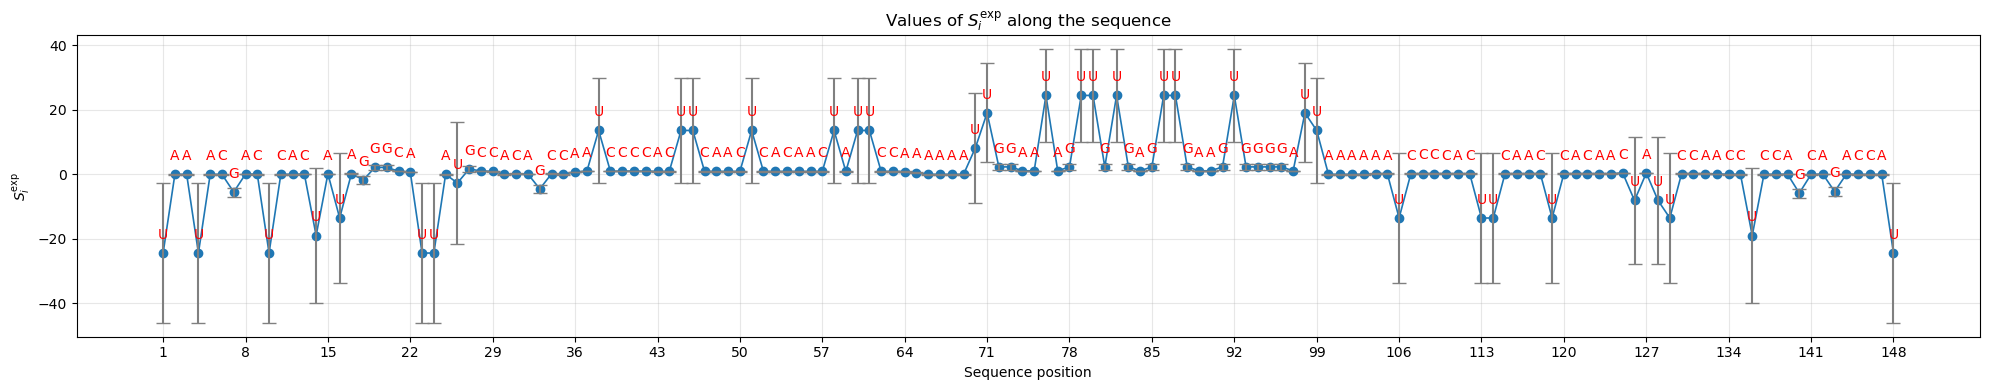

In [27]:
# positions along the sequence
positions = np.arange(1, len(sequence) + 1)

# b_from_fit is the array you already computed
y = target_contact_prob
y_errors = np.sqrt(squared_confidence_interval)

plt.figure(figsize=(20, 4))
ax = plt.gca()

ax.plot(positions, y, marker='o', linestyle='-', linewidth=1.2, color='tab:blue')
ax.errorbar(positions, y, yerr=y_errors, ecolor='gray', fmt='none', capsize=5)

# add nucleotide letters near each point
for x, yy, nt in zip(positions, y, sequence):
    ax.annotate(
        nt,
        xy=(x, yy),
        xytext=(0, 8),           # offset upward
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        color="red"
    )

ax.set_xticks(positions[::7])

ax.set_xlabel("Sequence position")
ax.set_ylabel(r"$S^{\text{exp}}_i$")
ax.set_title(r"Values of $S^{\text{exp}}_i$ along the sequence")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
target_contact_prob, squared_confidence_interval = compute_expansion_parameters(mutation_counts, coverage_per_site, a_from_merge, b_from_merge)

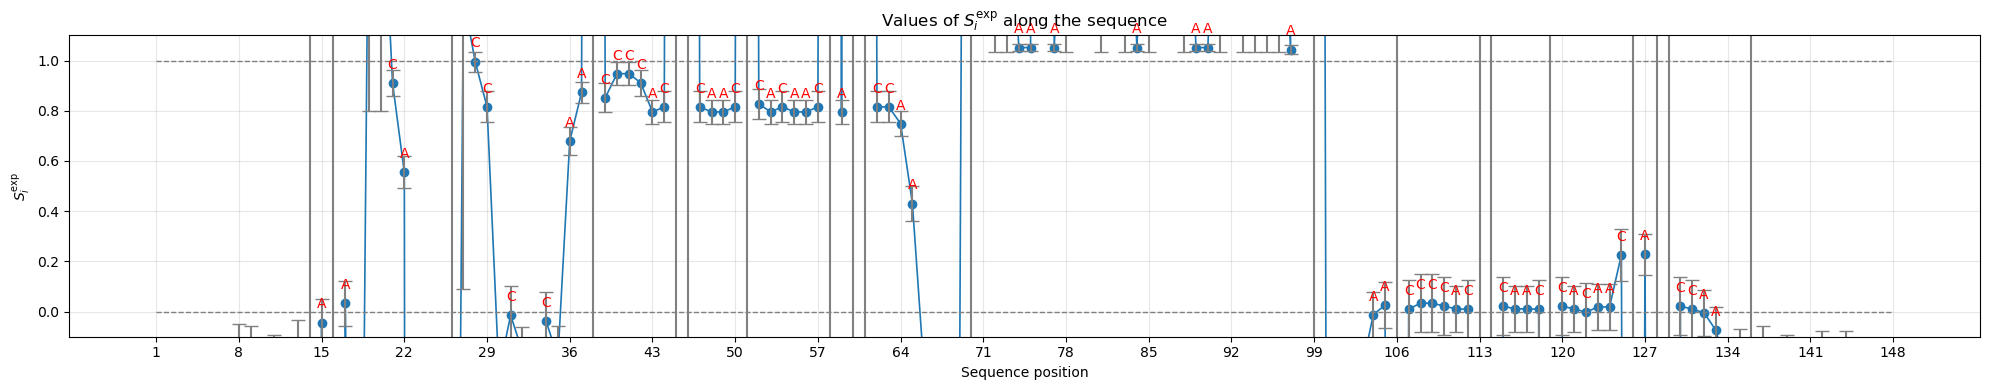

In [29]:
# positions along the sequence
positions = np.arange(1, len(sequence) + 1)

# b_from_fit is the array you already computed
y = target_contact_prob
y_errors = np.sqrt(squared_confidence_interval)

plt.figure(figsize=(20, 4))
ax = plt.gca()

ax.plot(positions, y, marker='o', linestyle='-', linewidth=1.2, color='tab:blue')
ax.errorbar(positions, y, yerr=y_errors, ecolor='gray', fmt='none', capsize=5)

# add nucleotide letters near each point
for x, yy, nt in zip(positions, y, sequence):
    ax.annotate(
        nt,
        xy=(x, yy),
        xytext=(0, 8),           # offset upward
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        color="red"
    )

ax.set_xticks(positions[::7])

ax.hlines(y=0, xmin=1, xmax=len(sequence), colors='gray', linestyles='dashed', linewidth=1)
ax.hlines(y=1, xmin=1, xmax=len(sequence), colors='gray', linestyles='dashed', linewidth=1)
ax.set_ylim(-0.1, 1.1)  # Set y-axis limits to ensure the dashed lines are visible

ax.set_xlabel("Sequence position")
ax.set_ylabel(r"$S^{\text{exp}}_i$")
ax.set_title(r"Values of $S^{\text{exp}}_i$ along the sequence")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 2 Max-Ent fit

In [30]:
def compute_penalty_m(temp_C, conc_mM, mu, p_b):
    '''Compute the penalty for paired bases in kcal/mol'''
    kBT = (273.15 + temp_C) * (1.98717/1000) # kcal/mol, matches fit.py's self.kBT = self.temp_K * kb
    beta = 1/kBT
    mu_j = mu + kBT * np.log((conc_mM+.1)/1000) if conc_mM is not None else mu
    mu_prime = mu_j-p_b
    penalty_in_kbt = -math.log((1+math.exp(beta*mu_prime))/(1+math.exp(beta*mu_j)))
    penalty_in_kcal_per_mol = penalty_in_kbt * kBT #TBC: to be checked
    return penalty_in_kcal_per_mol

In [31]:
def maxent(seq,bpp_ref,*, sigma_squared, penalty=None, boundaries=None, initial_guess=None, rescale=True,version=0,T=None,deriv_correct=False,alpha=0.0,tol=0.0001):
    # seq: sequence
    # bpp_ref: array with base pairing probabilities to be enforced
    # sigma_squared error estimate, enters in derivative and regularization
    
    # boundaries: apply boundaries on lambda.
    #   a number (e.g., 2), means all lambdas are in (-2,+2)
    #   alternatively, pass a (N,2) array with minumum (:,0) and maximum (:,1)
    
    # alpha: KL regularization
    from scipy.optimize import minimize

    if T is not None:
        save_T=RNA.cvar.temperature
        RNA.cvar.temperature=T
    
    fc=RNA.fold_compound(seq)
    if rescale:
        fc.mfe()
        fc.exp_params_rescale(0.01*fc.mfe()[1])
    
    if isinstance(boundaries,float):
        boundaries=boundaries*np.ones((len(seq),2))
        boundaries[:,0]*=-1
    
    def Gamma(lambdas):
        
        if deriv_correct:
            lambdas_rounded=np.round(lambdas,2)
            dlambdas=lambdas-lambdas_rounded
            lambdas=lambdas_rounded
        else:
            dlambdas=lambdas*0.0
        
        if penalty is not None:
            for i in range(len(seq)):
                for j in range(i+1,len(seq)):
                    fc.sc_add_bp(i+1,j+1,2*penalty) # penalty is already in kcal/mol
        
        shift=0.0
        for i in range(len(lambdas)):
            m=lambdas[i]
            if m==0:
                continue
            elif version==1 or (version==0 and m<0):
                fc.sc_add_up(i+1,-m) # vienna takes positions starting from 1
                shift+=m
            elif version==2 or (version==0 and m>0):
                for j in range(len(lambdas)):
                    if j>i:
                        fc.sc_add_bp(i+1,j+1,m)
                    if j<i:
                        fc.sc_add_bp(j+1,i+1,m)
        F=fc.pf()[1]+shift
        gamma=-F+np.dot(lambdas,bpp_ref)
        bpp = np.array(fc.bpp())[1:,1:]
        bpp+=bpp.T
        bpp=np.sum(bpp,axis=0)
        gradients=bpp_ref-bpp
        # correction on gamma - but it does not correct the gradients...
        # this means the minimization might fail
        
        gamma+=np.dot(gradients,dlambdas)
        
        # L2 regularization
        gamma+= 0.5*alpha*np.sum(sigma_squared*(lambdas+dlambdas)**2)
        gradients += alpha*sigma_squared*(lambdas+dlambdas)
        
        fc.sc_init()
        
        return gamma,gradients
    
    if initial_guess is None:
        initial_guess=np.zeros(len(seq))
    else:
        initial_guess=np.array(initial_guess)
    
    res=minimize(Gamma,initial_guess,jac=True,method="L-BFGS-B",bounds=boundaries,tol=tol)
        
        
    if T is not None:
        RNA.cvar.temperature=save_T
        
    return res,bpp_ref-res.jac+alpha*sigma_squared*res.x

In [46]:
# synthetic bistable pop0 from Giuseppe

bpp_target=target_contact_prob
penalties = compute_penalty_m(**phys_const_from_fit_metadata, mu=phys_params_dict['mu_r'], p_b=phys_params_dict['p_b'])

res=maxent(seq, bpp_target, sigma_squared=squared_confidence_interval, penalty= penalties, boundaries=1.0,alpha=10,deriv_correct=False, tol=1e-8,T=phys_const_from_fit_metadata['temp_C'])
res

(  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
   success: True
    status: 0
       fun: 42.807893830062355
         x: [ 4.033e-03  1.000e+00 ...  1.000e+00  4.033e-03]
       nit: 538
       jac: [-1.443e-02 -1.373e-01 ... -1.441e-01 -1.516e-02]
      nfev: 609
      njev: 609
  hess_inv: <148x148 LbfgsInvHessProduct with dtype=float64>,
 array([8.38653631e-04, 4.22203787e-04, 7.23162220e-04, 1.21775564e-03,
        7.55926387e-04, 1.87976282e-03, 1.11216304e-02, 2.57900393e-03,
        4.75940442e-03, 5.04078645e-03, 3.85022127e-03, 1.64319363e-04,
        5.25341999e-03, 5.79372212e-03, 4.68537467e-02, 8.61349253e-02,
        8.75441904e-02, 2.65560987e-01, 9.86604234e-01, 9.89968193e-01,
        9.18142473e-01, 5.63760386e-01, 4.88514361e-02, 4.10674566e-02,
        6.28206546e-05, 5.19533019e-01, 9.75571557e-01, 9.82363393e-01,
        9.04828151e-01, 2.72890472e-04, 8.46162576e-02, 7.71576563e-03,
        7.91712758e-02, 7.29122578e-02, 8.68541893e-03, 6.87532

In [34]:
def compute_ps_with_penalty_and_lambda(seq, lambdas, penalty, *, version=0, T=None, rescale=True):
    
    if T is not None:
        save_T=RNA.cvar.temperature
        RNA.cvar.temperature=T
    
    fc=RNA.fold_compound(seq)
    if rescale:
        fc.mfe()
        fc.exp_params_rescale(0.01*fc.mfe()[1])
    if penalty is not None:
        for i in range(len(seq)):
            for j in range(i+1,len(seq)):
                fc.sc_add_bp(i+1,j+1,2*penalty) # penalty is already in kcal/mol
    
    shift=0.0
    for i in range(len(lambdas)):
        m=lambdas[i]
        if m==0:
            continue
        elif version==1 or (version==0 and m<0):
            fc.sc_add_up(i+1,-m) # vienna takes positions starting from 1
            shift+=m
        elif version==2 or (version==0 and m>0):
            for j in range(len(lambdas)):
                if j>i:
                    fc.sc_add_bp(i+1,j+1,m)
                if j<i:
                    fc.sc_add_bp(j+1,i+1,m)
    fc.pf()
    bpp = np.array(fc.bpp())[1:,1:]
    bpp+=bpp.T
    bpp=np.sum(bpp,axis=0)

    return bpp

In [35]:
lambdas_merge_rna = vec_phys_params[8:]
bpp_mergerna = compute_ps_with_penalty_and_lambda(seq, lambdas_merge_rna, None, version=0, T=None, rescale=True)

In [36]:
bpp_mergerna_penalties = compute_ps_with_penalty_and_lambda(seq, lambdas_merge_rna, penalties, version=0, T=None, rescale=True)

In [ ]:
natural_min_lambda=-target_contact_prob/squared_confidence_interval
natural_max_lambda=(1-target_contact_prob)/squared_confidence_interval
plt.figure(figsize=(20, 4))
#plt.plot(range(len(lambdas_merge_rna)), natural_max_lambda, marker='*', linestyle='None', color='blue', label='maximum')
#plt.plot(range(len(lambdas_merge_rna)), natural_min_lambda, marker='o', linestyle='None', color='green', label='minima')
plt.errorbar(range(len(lambdas_merge_rna)), (natural_max_lambda+natural_min_lambda)/2, yerr=(natural_max_lambda-natural_min_lambda)/2, ecolor='gray', fmt='none', capsize=5)
plt.title(f'lambda_sc, ViennaRNA maxent')
plt.xlabel('Position')
plt.ylabel('lambda_sc')
#plt.ylim(-10, 10)  # Set y-axis limits
plt.yscale('symlog', linthresh=1e-2)  # Use symmetric log scale with a linear threshold
plt.legend()

In [ ]:
natural_max_lambda_bin=(coverage_per_site*a_from_merge-mutation_counts)*b_from_merge/(a_from_merge-a_from_merge**2)
natural_min_lambda_bin=(coverage_per_site*(a_from_merge+b_from_merge)-mutation_counts)*b_from_merge/((a_from_merge+b_from_merge)-(a_from_merge+b_from_merge)**2)
plt.figure()
plt.plot(range(len(lambdas_merge_rna)), natural_max_lambda_bin, marker='*', linestyle='None', color='blue', label='maximum')
plt.plot(range(len(lambdas_merge_rna)), natural_min_lambda_bin, marker='o', linestyle='None', color='green', label='minima')
plt.title(f'lambda_sc, ViennaRNA maxent')
plt.xlabel('Position')
plt.ylabel('lambda_sc')
#plt.ylim(-10, 10)  # Set y-axis limits
plt.yscale('symlog', linthresh=1e-2)  # Use symmetric log scale with a linear threshold
plt.legend()

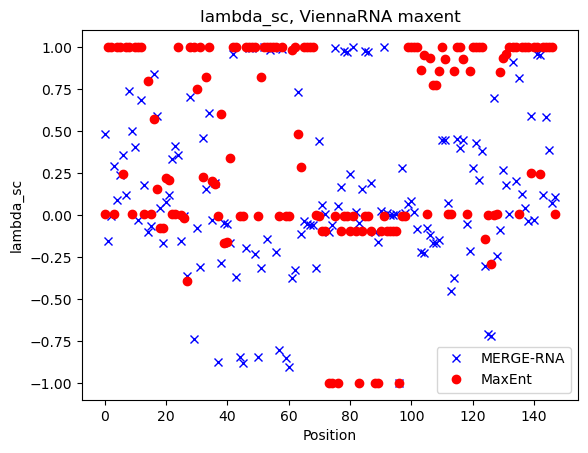

In [47]:
plt.figure()
plt.plot(range(len(lambdas_merge_rna)), lambdas_merge_rna, marker='x', linestyle='None', color='blue', label='MERGE-RNA')
plt.plot(res[0].x, marker='o', linestyle='None', color='red', label='MaxEnt')
plt.title(f'lambda_sc, ViennaRNA maxent')
plt.xlabel('Position')
plt.ylabel('lambda_sc')
plt.legend()

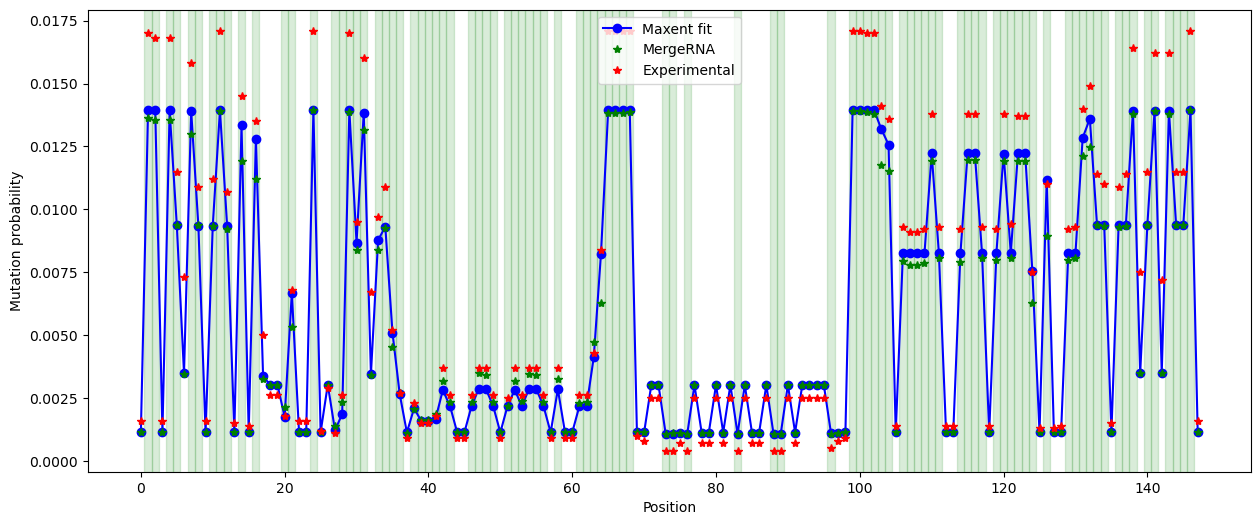

In [48]:
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(15, 6))

# plot your main series
ax.plot(a_from_merge+b_from_merge*res[1], marker='o', linestyle='-', color='blue', label='Maxent fit')
ax.plot(a_from_merge+b_from_merge*bpp_mergerna, marker='*', linestyle=' ', color='green', label='MergeRNA')
ax.plot(mutation_counts/coverage_per_site, marker='*', linestyle=' ', color='red', label='Experimental')

# shade regions based on the sequence
for i, nt in enumerate(sequence):
    if nt in ['A', 'C']:
        ax.axvspan(i - 0.5, i + 0.5, color='green', alpha=0.15, zorder=0)

ax.set_xlabel('Position')
ax.set_ylabel('Mutation probability')
ax.legend()
plt.show()

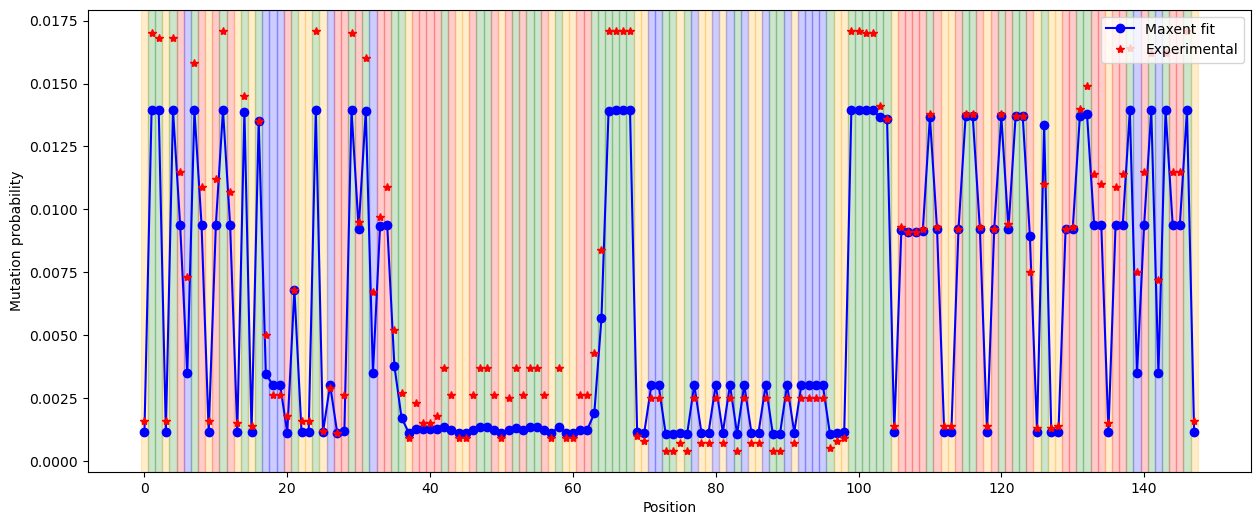

In [39]:
fig, ax = plt.subplots(figsize=(15, 6))

# plot your main series
ax.plot(a_from_merge+b_from_merge*res[1], marker='o', linestyle='-', color='blue', label='Maxent fit')
ax.plot(mutation_counts/coverage_per_site, marker='*', linestyle=' ', color='red', label='Experimental')

# shade regions based on the sequence
color_map = {'A': 'green', 'C': 'red', 'G': 'blue', 'U': 'orange'}

for i, nt in enumerate(sequence):
    if nt in color_map:
        ax.axvspan(i - 0.5, i + 0.5, color=color_map[nt], alpha=0.2, zorder=0)

ax.set_xlabel('Position')
ax.set_ylabel('Mutation probability')
ax.legend()
plt.show()

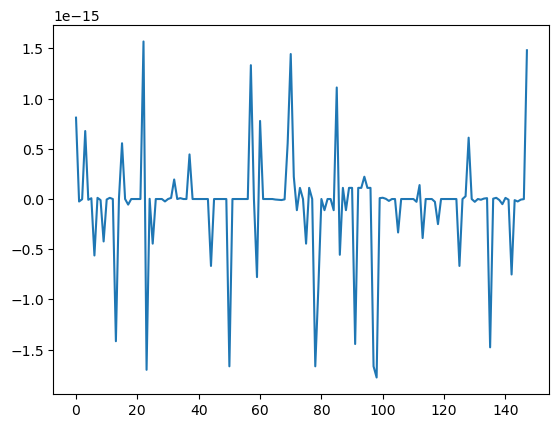

In [49]:
plt.plot(compute_ps_with_penalty_and_lambda(seq, res[0].x, penalties, version=0, T=None, rescale=True)-res[1])

(0.0, 1.0)

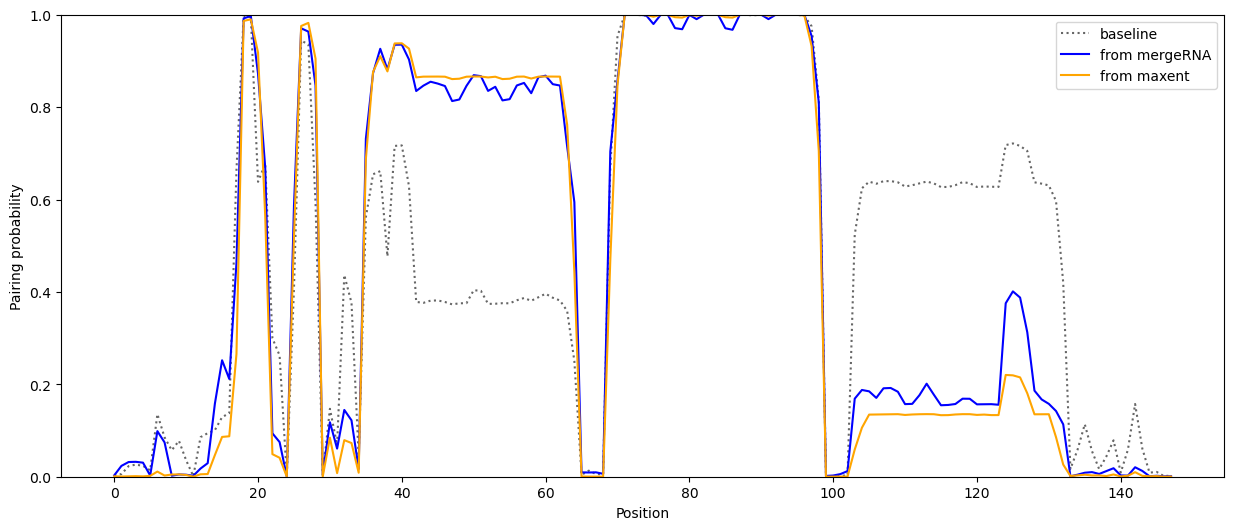

In [50]:
indices = np.arange(len(seq))
pp_baseline = bpp
#pp_maxent = res[1]
pp_maxent = compute_ps_with_penalty_and_lambda(seq, res[0].x, penalties, version=0, T=None, rescale=True)
pp_merge = bpp_mergerna

fig, ax = plt.subplots(1, 1, figsize=(15, 6))
ax.plot(indices, pp_baseline, label='baseline', linestyle=':', color='black', alpha=.6, linewidth=1.5)
ax.plot(indices, pp_merge, label=f'from mergeRNA', linestyle='-', color='blue')
ax.plot(indices, pp_maxent, label=f'from maxent', linestyle='-', color='orange')
ax.set_xlabel('Position')
ax.set_ylabel('Pairing probability')
ax.legend()
ax.set_ylim(0,1)

In [ ]:
def loss_of_maxent(*, mut_rate_model, mut_obs, coverage, a_i, b_i):
    """
    Compute the negative loss of MAXent, so the quadratic expansion of the log-likelihood with respect to the parameters.

    Inputs:
        mut_rate_model: np.array, predicted mutation profile (values in (0,1))
        grad_of_mut_rate:    np.array, derivative matrix of the mutation profile with respect to parameters.
        compute_gradient: bool, whether to compute the gradient.
    Returns:
        loss: scalar, the negative log-likelihood loss.
    """
    
    # Apply position mask to exclude masked positions from loss calculation
    ### not for now I do not mask positions
    # mut_obs_masked = mut_obs[self.position_mask]
    # coverage_masked = coverage[self.position_mask] 
    # mut_rate_model_masked = mut_rate_model[self.position_mask]
    mut_obs_masked = mut_obs
    coverage_masked = coverage
    mut_rate_model_masked = mut_rate_model
    # Numerical guard: prevent log/division singularities at exactly 0 or 1.
    # Keep epsilon tiny so low mutation-rate regime is not materially altered.
    eps_num = 1e-15
    mut_rate_model_masked = np.clip(mut_rate_model_masked, eps_num, 1.0 - eps_num)
    
    
    # Compute log of the binomial coefficient for each position
    log_binom = np.array([log_binomial(cov, mut) for cov, mut in zip(coverage_masked, mut_obs_masked)])
    # Compute the log-likelihood at each position at the max, so mut prob is given by mut count
    mut_observed = mut_obs_masked / coverage_masked
    log_prob_at_max = log_binom + (mut_obs_masked * np.log(mut_observed) +
                            (coverage_masked - mut_obs_masked) * np.log(1 - mut_observed))

    S_exp_i, sigma_squared_i = compute_expansion_parameters(mut_obs_masked, coverage_masked, a_i, b_i)
    S_from_model = (mut_rate_model_masked-a_i)/b_i
    ki_squared = (S_from_model - S_exp_i)**2 / sigma_squared_i
    
    # Total negative log-likelihood loss (only from unmasked positions)
    loss = -np.sum(log_prob_at_max) + 0.5 * np.sum(ki_squared) 
    
    return loss

In [51]:
# true loss evaluated from maxent pairing probs
loss_binomial(mut_rate_model=my_mut_rate_profile(res[1],a_from_merge, b_from_merge), mut_obs=mutation_counts, coverage=coverage_per_site)

np.float64(619.6854902683092)

In [52]:
# true loss evaluated from merge rna pairing probs
loss_binomial(mut_rate_model=my_mut_rate_profile(bpp_mergerna,a_from_merge, b_from_merge), mut_obs=mutation_counts, coverage=coverage_per_site)

np.float64(647.214051863672)

In [53]:
# true loss evaluated from merge rna pairing probs with penalties
loss_binomial(mut_rate_model=my_mut_rate_profile(bpp_mergerna_penalties,a_from_merge, b_from_merge), mut_obs=mutation_counts, coverage=coverage_per_site)

np.float64(642.9487050911398)

In [ ]:
# maxent loss evaluated from maxent pairing probs
loss_of_maxent(mut_rate_model=my_mut_rate_profile(res[1],a_from_merge, b_from_merge), mut_obs=mutation_counts, coverage=coverage_per_site, a_i=a_from_merge, b_i=b_from_merge)

In [ ]:
# maxent loss evaluated from merge rna pairing probs
loss_of_maxent(mut_rate_model=my_mut_rate_profile(bpp_mergerna,a_from_merge, b_from_merge), mut_obs=mutation_counts, coverage=coverage_per_site, a_i=a_from_merge, b_i=b_from_merge)

Now I try to run maxent starting from the merge-rna minimum

In [54]:
res_new_init_guess=maxent(seq, bpp_target, sigma_squared=squared_confidence_interval, penalty= penalties, initial_guess=lambdas_merge_rna, boundaries=1.0,alpha=0.,deriv_correct=False, tol=1e-8)
res_new_init_guess

(  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
   success: True
    status: 0
       fun: -795.3759438034812
         x: [ 1.000e+00  1.000e+00 ...  1.000e+00  1.000e+00]
       nit: 36
       jac: [-3.320e+01 -2.378e-01 ... -2.455e-01 -3.320e+01]
      nfev: 38
      njev: 38
  hess_inv: <148x148 LbfgsInvHessProduct with dtype=float64>,
 array([1.63302233e-04, 9.81526297e-05, 1.08717153e-04, 1.69216316e-04,
        7.18846936e-05, 6.00325226e-04, 6.13106727e-03, 6.24964403e-04,
        1.16014696e-03, 1.04961214e-03, 1.01329570e-03, 4.00016502e-05,
        1.01917304e-03, 5.62566310e-04, 4.69802625e-03, 2.99863504e-02,
        3.41622121e-02, 6.81843807e-02, 9.97198618e-01, 9.99290262e-01,
        9.93276188e-01, 5.52377744e-01, 3.65385862e-04, 8.27561450e-05,
        2.23020223e-06, 5.51891671e-01, 9.95432459e-01, 9.95559057e-01,
        9.86777557e-01, 8.81675367e-05, 1.84554574e-02, 1.62399328e-03,
        4.50563764e-03, 3.56628865e-03, 1.07056122e-03, 7.89177034

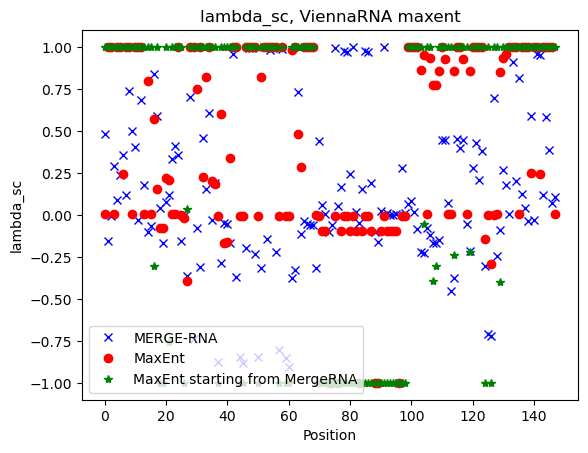

In [55]:
plt.figure()
plt.plot(range(len(lambdas_merge_rna)), lambdas_merge_rna, marker='x', linestyle='None', color='blue', label='MERGE-RNA')
plt.plot(res[0].x, marker='o', linestyle='None', color='red', label='MaxEnt')
plt.plot(res_new_init_guess[0].x, marker='*', linestyle='None', color='green', label='MaxEnt starting from MergeRNA')
plt.title(f'lambda_sc, ViennaRNA maxent')
plt.xlabel('Position')
plt.ylabel('lambda_sc')
plt.legend()

In [56]:
# maxent loss evaluated from maxent pairing probs obtained from merge initial guess
loss_of_maxent(mut_rate_model=my_mut_rate_profile(res_new_init_guess[1],a_from_merge, b_from_merge), mut_obs=mutation_counts, coverage=coverage_per_site, a_i=a_from_merge, b_i=b_from_merge)

NameError: name 'loss_of_maxent' is not defined

In [57]:
# true loss evaluated from maxent pairing probs obtained from merge initial guess
loss_binomial(mut_rate_model=my_mut_rate_profile(res_new_init_guess[1],a_from_merge, b_from_merge), mut_obs=mutation_counts, coverage=coverage_per_site)

np.float64(772.6432539656523)

In [ ]:
def maxent_binomial(seq, mutation_counts, trials_counts, a_phys, b_phys,*, penalty=None, boundaries=None, initial_guess=None, rescale=True,version=0,T=None,deriv_correction=False,alpha=0.0,tol=0.0001):
    # seq: sequence
    # mutation_counts: array with number of mutations counted per site
    # trials_counts: array with number of attempted mutations per site

    # a_phys, b_phys: arrays of physical parameters for the mutation probability

    # boundaries: apply boundaries on lambda.
    #   a number (e.g., 2), means all lambdas are in (-2,+2)
    #   alternatively, pass a (N,2) array with minumum (:,0) and maximum (:,1)
    
    # alpha: KL regularization
    from scipy.optimize import minimize

    if T is not None:
        save_T=RNA.cvar.temperature
        RNA.cvar.temperature=T

    kb=1.98717/1000 # grepped from vienna source code
    kBT = ((RNA.cvar.temperature + 273.15) * kb)
    beta = 1.0/kBT
    
    fc=RNA.fold_compound(seq)
    if rescale:
        fc.mfe()
        fc.exp_params_rescale(0.01*fc.mfe()[1])
    
    if isinstance(boundaries,float):
        boundaries=boundaries*np.ones((len(seq),2))
        boundaries[:,0]*=-1
    elif boundaries is None:
        boundaries = np.array([(None, None)]*len(seq))

    frac_phys = a_phys/b_phys
    inv_b_phys = 1.0/b_phys

    def inverse_loss_derivative(lams):
        # lams must be adimensional
        # when lams is 0 (or alpha is 0), the results should be frac_phys + inv_b_phys*mutation_counts/trials_counts
        lams_prime = lams*alpha/b_phys
        S = np.sqrt((trials_counts - lams_prime)**2 + 4*mutation_counts*lams_prime)
        result =  -frac_phys + inv_b_phys*2*mutation_counts / (S - (lams_prime - trials_counts))
        #print(result-(-frac_phys+inv_b_phys*mutation_counts/trials_counts))
        return result

    def loss_binomial(bpp_1):
        mut_prob = a_phys+b_phys*bpp_1
        return -mutation_counts*np.log(mut_prob)-(trials_counts-mutation_counts)*np.log(1-mut_prob)
    
    def deriv_loss_binomial(bpp_1):
        mut_prob = a_phys+b_phys*bpp_1
        return -b_phys*mutation_counts/mut_prob+b_phys*(trials_counts-mutation_counts)/(1-mut_prob)

    def Gamma(lambdas):
        
        if deriv_correction:
            lambdas_rounded=np.round(lambdas,2)
            dlambdas=lambdas-lambdas_rounded
            lambdas=lambdas_rounded
        else:
            dlambdas=lambdas*0.0
        
        if penalty is not None:
            for i in range(len(seq)):
                for j in range(i+1,len(seq)):
                    fc.sc_add_bp(i+1,j+1,2*penalty) # penalty is already in kcal/mol
        
        shift=0.0
        for i in range(len(lambdas)):
            m=lambdas[i]
            if m==0:
                continue
            elif version==1 or (version==0 and m<0):
                fc.sc_add_up(i+1,-m) # vienna takes positions starting from 1
                shift+=m
            elif version==2 or (version==0 and m>0):
                for j in range(len(lambdas)):
                    if j>i:
                        fc.sc_add_bp(i+1,j+1,m)
                    if j<i:
                        fc.sc_add_bp(j+1,i+1,m)
        F=fc.pf()[1] + shift

        bpp_lambda = inverse_loss_derivative(beta*lambdas) # need to make lambdas adimensional
        gamma=beta*(-F+np.dot(lambdas,bpp_lambda))
        
        bpp = np.array(fc.bpp())[1:,1:]
        bpp+=bpp.T
        bpp=np.sum(bpp,axis=0)
        gradients = -bpp + bpp_lambda #here I didn't put beta
        # correction on gamma - but it does not correct the gradients...
        # this means the minimization might fail
        
        gamma+=np.dot(gradients,dlambdas)
        
        # alpha regularization

        if alpha > 0:
            gamma+= -(1.0/alpha)*np.sum(loss_binomial(bpp_lambda))
        # otherwise this becomes a constant diverging term = -1/alpha * mim(binmial_loss)
        
        # alpha enters in the gradients by default so no need to add a term for alpha!=0
        # but if it is equal to zero the gradients are just chasing the pairing prob that gives the exp mutation for given a_phys, b_phys
        
        fc.sc_init()
        
        return gamma,gradients
    
    if initial_guess is None:
        initial_guess=np.zeros(len(seq))
    else:
        initial_guess=np.array(initial_guess)
    
    res=minimize(Gamma,initial_guess,jac=True,method="L-BFGS-B",bounds=boundaries,tol=tol)
        
        
    if T is not None:
        RNA.cvar.temperature=save_T
    
    # return the result of the optimization and the average pairing probs corrected by a non zero gradient
    return res,inverse_loss_derivative(beta*res.x)-res.jac

In [ ]:
res_binom=maxent_binomial(seq, mutation_counts=mutation_counts, trials_counts=coverage_per_site, a_phys=a_from_merge, b_phys=b_from_merge, penalty= penalties, boundaries=1.0,alpha=0.,deriv_correction=False, tol=1e-8,T=phys_const_from_fit_metadata['temp_C'])
res_binom

In [ ]:
plt.figure()
plt.plot(range(len(lambdas_merge_rna)), lambdas_merge_rna, marker='x', linestyle='None', color='blue', label='MERGE-RNA')
plt.plot(res[0].x, marker='o', linestyle='None', color='red', label='MaxEnt')
plt.plot(res_binom[0].x, marker='*', linestyle='None', color='green', label='MaxEnt binomial')
plt.title(f'lambda_sc, ViennaRNA maxent')
plt.xlabel('Position')
plt.ylabel('lambda_sc')
plt.legend()

In [ ]:
#plot the difference between the ps computed from lambdas and the value obtained by inverting the definition of the maxent gradient
plt.plot(compute_ps_with_penalty_and_lambda(seq, res_binom[0].x, penalties, version=0, T=None, rescale=True)-res_binom[1])

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))

# plot your main series
ax.plot(res[0].jac, marker='o', linestyle='-', color='blue', label='Maxent gradient')

# shade regions based on the sequence
lam_values = res[0].x
for i, lam in enumerate(lam_values):
    if math.isclose(1.,lam):
        ax.axvspan(i - 0.5, i + 0.5, color='green', alpha=0.15, zorder=0)
    elif math.isclose(-1.,lam):
        ax.axvspan(i - 0.5, i + 0.5, color='red', alpha=0.15, zorder=0)

ax.set_xlabel('Position of lambda')
ax.set_ylabel('Gradient wrt lambda')
ax.legend()
plt.show()

In [ ]:
zero_positions = []
strict_range = 0.01
for i in range(len(seq)):
    if -strict_range<res[0].jac[i]<strict_range:
        zero_positions.append(i)

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))

# shade regions based on the sequence
bpp_exp = bpp_target
for i, pair_prob_exp in enumerate(bpp_exp):
    if pair_prob_exp < 1 and pair_prob_exp>0:
        ax.axvspan(i - 0.5, i + 0.5, color='green', alpha=0.15, zorder=0)

# plot your main series
ax.plot(res[0].jac, marker='o', linestyle='-', color='blue', label='Maxent gradient')
ax.plot(zero_positions,res[0].jac[zero_positions], "*", color='pink', label='|gradient|<'+str(strict_range))

ax.set_xlabel('Position of lambda')
ax.set_ylabel('Gradient wrt lambda')
ax.legend()
plt.show()

In [ ]:
loss_binomial(mut_rate_model=my_mut_rate_profile(res_binom[1],a_from_merge, b_from_merge), mut_obs=mutation_counts, coverage=coverage_per_site)

### Try the optimization with natural boundaries

In [ ]:
natural_min_lambda=-target_contact_prob/squared_confidence_interval
natural_max_lambda=(1-target_contact_prob)/squared_confidence_interval
maxent_bounds = np.array([(natural_min_lambda[i], natural_max_lambda[i]) for i in range(len(natural_min_lambda))])

In [ ]:
alpha = 0.01
kb=1.98717/1000 # grepped from vienna source code
kBT = ((RNA.cvar.temperature + 273.15) * kb)
beta = 1.0/kBT

maxent_bounds = maxent_bounds/(beta*alpha)
res_b=maxent(seq, bpp_target, sigma_squared=squared_confidence_interval, penalty= penalties, boundaries=maxent_bounds,alpha=alpha,deriv_correct=False, tol=1e-8,T=phys_const_from_fit_metadata['temp_C'])
res_b

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))

# plot your main series
ax.plot(a_from_merge+b_from_merge*res_b[1], marker='o', linestyle='-', color='blue', label='Maxent fit')
ax.plot(a_from_merge+b_from_merge*bpp_mergerna, marker='*', linestyle=' ', color='green', label='MergeRNA')
ax.plot(mutation_counts/coverage_per_site, marker='*', linestyle=' ', color='red', label='Experimental')

# shade regions based on the sequence
for i, nt in enumerate(sequence):
    if nt in ['A', 'C']:
        ax.axvspan(i - 0.5, i + 0.5, color='green', alpha=0.15, zorder=0)

ax.set_xlabel('Position')
ax.set_ylabel('Mutation probability')
ax.legend()
plt.show()

In [ ]:
indices = np.arange(len(seq))
pp_baseline = bpp
#pp_maxent = res[1]
pp_maxent = compute_ps_with_penalty_and_lambda(seq, res_b[0].x, penalties, version=0, T=None, rescale=True)
pp_merge = bpp_mergerna

fig, ax = plt.subplots(1, 1, figsize=(15, 6))
ax.plot(indices, pp_baseline, label='baseline', linestyle=':', color='black', alpha=.6, linewidth=1.5)
ax.plot(indices, pp_merge, label=f'from mergeRNA', linestyle='-', color='blue')
ax.plot(indices, pp_maxent, label=f'from maxent', linestyle='-', color='orange')
ax.set_xlabel('Position')
ax.set_ylabel('Pairing probability')
ax.legend()
ax.set_ylim(0,1)

In [ ]:
loss_binomial(mut_rate_model=my_mut_rate_profile(res_b[1],a_from_merge, b_from_merge), mut_obs=mutation_counts, coverage=coverage_per_site)

### 2.4 Alpha scan: restoring the $\sigma$-weighting in the MaxEnt dual

`sigma_squared` only enters `Gamma(lambdas)` multiplied by `alpha` (the L2/regularization term). Both fits above used `alpha=0.`, so `sigma_squared` had **no effect** on the optimization: `maxent` was doing an exact-match Legendre dual, trying to hit every `target_contact_prob_i` with equal weight regardless of how uncertain it is (`squared_confidence_interval_i`). That's the likely cause of both the boundary-hugging $\lambda$'s and of the warm-started fit (`res_new_init_guess`) landing on a *worse* `loss_of_maxent` than the merge_rna starting point.

Below: scan `alpha` first at the original optimizer tolerance, then repeat at a tighter tolerance, and check both loss behavior and how far the resulting $\lambda$'s end up from `lambdas_merge_rna`.

In [ ]:
def lambda_vs_merge_metrics(lambdas, lambdas_ref, *, boundary=1.0, atol=1e-3):
    '''Effective distance between a fitted lambda vector and lambdas_merge_rna.'''
    diff = lambdas - lambdas_ref
    rmse = np.sqrt(np.mean(diff**2))
    corr = np.corrcoef(lambdas, lambdas_ref)[0, 1]
    max_abs_diff = np.max(np.abs(diff))
    n_at_boundary = np.sum(np.isclose(np.abs(lambdas), boundary, atol=atol))
    return rmse, corr, max_abs_diff, n_at_boundary


def run_alpha_scan(alphas, *, tol, initial_guess):
    '''Run maxent() across a range of alpha values and collect loss + convergence + lambda-agreement metrics.'''
    records = []
    for a in alphas:
        res_a, bpp_a = maxent(seq, bpp_target, sigma_squared=squared_confidence_interval,
                               penalty=penalties, initial_guess=initial_guess.copy(),
                               boundaries=1.0, alpha=a, tol=tol, deriv_correct=False)
        mut_rate_a = my_mut_rate_profile(bpp_a, a_from_merge, b_from_merge)
        l_maxent = loss_of_maxent(mut_rate_model=mut_rate_a, mut_obs=mutation_counts,
                                   coverage=coverage_per_site, a_i=a_from_merge, b_i=b_from_merge)
        l_exact = loss_binomial(mut_rate_model=mut_rate_a, mut_obs=mutation_counts,
                                 coverage=coverage_per_site)
        rmse, corr, max_abs_diff, n_bound = lambda_vs_merge_metrics(res_a.x, lambdas_merge_rna)
        records.append(dict(alpha=a, converged=res_a.success, n_iter=res_a.nit,
                             loss_of_maxent=l_maxent, loss_binomial=l_exact,
                             n_at_boundary=n_bound, rmse_vs_merge=rmse,
                             corr_vs_merge=corr, max_abs_diff_vs_merge=max_abs_diff))
    return pd.DataFrame.from_records(records)


# reference losses: merge_rna's own lambdas (with the physical penalty applied), for horizontal lines in the plots
loss_of_maxent_at_merge = loss_of_maxent(
    mut_rate_model=my_mut_rate_profile(bpp_mergerna_penalties, a_from_merge, b_from_merge),
    mut_obs=mutation_counts, coverage=coverage_per_site, a_i=a_from_merge, b_i=b_from_merge)
loss_binomial_at_merge = loss_binomial(
    mut_rate_model=my_mut_rate_profile(bpp_mergerna_penalties, a_from_merge, b_from_merge),
    mut_obs=mutation_counts, coverage=coverage_per_site)

alphas_scan = np.concatenate([[0.0], np.logspace(-2, 1, 13)])
print(f"loss_of_maxent at merge_rna lambdas: {loss_of_maxent_at_merge:.2f}")
print(f"loss_binomial (exact) at merge_rna lambdas: {loss_binomial_at_merge:.2f}")

In [ ]:
# Scan at the notebook's original optimizer tolerance (tol=1e-4), warm-started from lambdas_merge_rna
# -- this is the setting that produced the reported "warm start makes the loss worse" behavior at alpha=0.
scan_df_tol1e4 = run_alpha_scan(alphas_scan, tol=1e-4, initial_guess=lambdas_merge_rna)
scan_df_tol1e4

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

ax = axes[0, 0]
ax.plot(scan_df_tol1e4['alpha'], scan_df_tol1e4['loss_of_maxent'], 'o-', label='loss_of_maxent (warm start)')
ax.plot(scan_df_tol1e4['alpha'], scan_df_tol1e4['loss_binomial'], 's--', label='loss_binomial (exact)', alpha=0.7)
ax.axhline(loss_of_maxent_at_merge, color='gray', linestyle=':', label='loss_of_maxent at merge_rna λ')
ax.set_xscale('symlog', linthresh=1e-2)
ax.set_xlabel('alpha'); ax.set_ylabel('loss')
ax.set_title('Loss vs alpha (tol=1e-4)')
ax.legend(fontsize=8)

ax = axes[0, 1]
ax.plot(scan_df_tol1e4['alpha'], scan_df_tol1e4['n_at_boundary'], 'o-', color='tab:red')
ax.set_xscale('symlog', linthresh=1e-2)
ax.set_xlabel('alpha'); ax.set_ylabel('# lambdas at |lambda|=1 boundary')
ax.set_title('Boundary-hugging vs alpha (tol=1e-4)')

ax = axes[1, 0]
ax.plot(scan_df_tol1e4['alpha'], scan_df_tol1e4['rmse_vs_merge'], 'o-', color='tab:green')
ax.set_xscale('symlog', linthresh=1e-2)
ax.set_xlabel('alpha'); ax.set_ylabel('RMSE(lambda_maxent, lambda_merge_rna)')
ax.set_title('Distance from merge_rna lambdas vs alpha')

ax = axes[1, 1]
ax.plot(scan_df_tol1e4['alpha'], scan_df_tol1e4['corr_vs_merge'], 'o-', color='tab:purple')
ax.set_xscale('symlog', linthresh=1e-2)
ax.set_xlabel('alpha'); ax.set_ylabel('corr(lambda_maxent, lambda_merge_rna)')
ax.set_title('Correlation with merge_rna lambdas vs alpha')

plt.tight_layout()
plt.show()

Now repeat the same scan with a tightened optimizer tolerance, to check whether the non-monotonic behavior above is a real effect of `alpha` or an artifact of `L-BFGS-B` not fully converging at `tol=1e-4`. **Watch `alpha=0` in particular**: since `sigma_squared` has no effect there, tighter convergence just lets it chase the unreliable/out-of-range targets harder -- `loss_of_maxent` can keep dropping while boundary-hugging and disagreement with `lambdas_merge_rna` get worse, not better.

In [ ]:
# Same scan, tighter tolerance
scan_df_tol1e8 = run_alpha_scan(alphas_scan, tol=1e-8, initial_guess=lambdas_merge_rna)
scan_df_tol1e8

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(scan_df_tol1e4['alpha'], scan_df_tol1e4['loss_of_maxent'], 'o-', label='tol=1e-4 (original)')
ax.plot(scan_df_tol1e8['alpha'], scan_df_tol1e8['loss_of_maxent'], 's-', label='tol=1e-8 (tightened)')
ax.axhline(loss_of_maxent_at_merge, color='gray', linestyle=':', label='loss at merge_rna λ')
ax.set_xscale('symlog', linthresh=1e-2)
ax.set_xlabel('alpha'); ax.set_ylabel('loss_of_maxent')
ax.set_title('Effect of optimizer tolerance on the alpha scan')
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(scan_df_tol1e4['alpha'], scan_df_tol1e4['n_at_boundary'], 'o-', label='tol=1e-4')
ax.plot(scan_df_tol1e8['alpha'], scan_df_tol1e8['n_at_boundary'], 's-', label='tol=1e-8')
ax.set_xscale('symlog', linthresh=1e-2)
ax.set_xlabel('alpha'); ax.set_ylabel('# lambdas at boundary')
ax.set_title('Boundary-hugging: tolerance sensitivity')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# NOTE: do not just take argmin(loss_of_maxent) across the scan -- at alpha=0 that number keeps
# improving as the optimizer converges further (tol=1e-8 beats tol=1e-4, even undercutting the
# merge_rna baseline), precisely because alpha=0 is the unweighted exact-match dual: it can always
# lower loss_of_maxent further by chasing the unreliable/out-of-range targets harder, at the cost of
# more lambdas pinned to the +-1 boundary and worse agreement with lambdas_merge_rna. Check both.
naive_best = scan_df_tol1e8.loc[scan_df_tol1e8['loss_of_maxent'].idxmin()]
print("Naive argmin(loss_of_maxent) pick (tol=1e-8):")
print(f"  alpha={naive_best['alpha']:.4g}  loss_of_maxent={naive_best['loss_of_maxent']:.2f}  "
      f"n_at_boundary={naive_best['n_at_boundary']:.0f}/{len(seq)}  corr_vs_merge={naive_best['corr_vs_merge']:.3f}")
print("  -> low loss here comes with high boundary-hugging and low correlation to merge_rna: a bad pick.\n")

# Instead, restrict to alphas that are NOT boundary-hugging pathologies (n_at_boundary in the
# "settled" low-and-stable regime seen in the scan/plots above), then take the lowest loss among those.
stable = scan_df_tol1e8[scan_df_tol1e8['n_at_boundary'] <= scan_df_tol1e8['n_at_boundary'].quantile(0.5)]
robust_best = stable.loc[stable['loss_of_maxent'].idxmin()]
chosen_alpha = robust_best['alpha']
print(f"Robustness-filtered pick: alpha={chosen_alpha:.4g}  loss_of_maxent={robust_best['loss_of_maxent']:.2f}  "
      f"n_at_boundary={robust_best['n_at_boundary']:.0f}/{len(seq)}  corr_vs_merge={robust_best['corr_vs_merge']:.3f}")

res_best, bpp_best = maxent(seq, bpp_target, sigma_squared=squared_confidence_interval,
                             penalty=penalties, initial_guess=lambdas_merge_rna.copy(),
                             boundaries=1.0, alpha=chosen_alpha, tol=1e-8, deriv_correct=False)
lambdas_best = res_best.x

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(lambdas_merge_rna, lambdas_best, s=15, alpha=0.7)
lims = [-1.05, 1.05]
ax.plot(lims, lims, 'k--', linewidth=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('lambda_merge_rna'); ax.set_ylabel(f'lambda_maxent (alpha={chosen_alpha:.3g})')
ax.set_title('Per-position agreement')

ax = axes[1]
positions = np.arange(1, len(seq) + 1)
ax.plot(positions, lambdas_best - lambdas_merge_rna, '.-')
ax.axhline(0, color='gray', linewidth=1)
ax.set_xlabel('Sequence position'); ax.set_ylabel('lambda_maxent - lambda_merge_rna')
ax.set_title('Per-position difference')

plt.tight_layout()
plt.show()

rmse, corr, max_abs_diff, n_bound = lambda_vs_merge_metrics(lambdas_best, lambdas_merge_rna)
print(f"RMSE(lambda_maxent, lambda_merge_rna) = {rmse:.4f}")
print(f"Correlation                            = {corr:.4f}")
print(f"Max |difference|                       = {max_abs_diff:.4f}")
print(f"# at boundary (|lambda|~1)              = {n_bound}/{len(seq)}")

I want to save the result of maxent to run it using merge-rna

In [ ]:
vec_all_params_to_save = np.concatenate([vec_phys_params[:8], res[0].x])
len(vec_all_params_to_save)

In [ ]:
np.savetxt("/home/mauro-maglione/Documents/MERGE-RNA/my_merge_rna/params1D_maxent.txt", vec_all_params_to_save)